# Causal forest

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import statsmodels.api as sm

from econml.dml import CausalForestDML # Causal forest with double machine learning
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier 

## Define mRS outcome target and cutoff for early treatment

In [2]:
MRS_TARGET = 2 # Model will set y as being less than or equal to this value

CUTOFF = 270

## Define adjustment fields

In [3]:
NON_CATEGORICAL_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'year',
    'onset_to_scan_time'
]

CATEGORICAL_FEATURES = [
    'stroke_team',
    'ethnicity',
    'treatment_group'
]

"""
X is the set of variables you want the treatment effect to depend on. # The causal forest builds 
trees that split on X, grouping patients so that the treatment effect is roughly constant within
a leaf.

W is the set of variables you want to control for. The causal forest will adjust for these 
variables, but will not split on them.

A feature belongs in X if you think the treatment effect may vary with it, and in W if it's a
confounder you need to adjust away. Many variables are both a confounder and an effect modifier, 
so they legitimately belong in both groups.
"""


X_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'ethnicity',
]

W_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'ethnicity',
    'stroke_team',
    'year',
    'onset_to_scan_time'
]

TREATMENTS = [
    'onset_to_thrombolysis_time',
    'onset_to_thrombectomy_time',
]

# Combine the X and W treatment features into a single list of features
cf_features = list(set(X_FEATURES + W_FEATURES + TREATMENTS))

## Load and filter data

In [4]:
data = pd.read_csv("../../data/sam3/cleaned_data.csv", low_memory=False)

# Calculate onset_to_scan
data["onset_to_scan_time"] = data["onset_to_arrival_time"] - data["arrival_to_scan_time"]

print(f"Initial data shape: {data.shape}")

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only infarction cases
data = data[data["infarction"] == 1]

# Keep only onset to arrival < 360 mins
data = data[data["onset_to_arrival_time"] < 360]

# Keep only perfusion_imaging_used == 0
data = data[data["perfusion_imaging_used"] == 0]

# Limit to stroke severity  > 5 
data = data[((data["stroke_severity"] > 5) | data["lvo"] == 1)]

# Keep only teams with at least 10 onset_to_thrombectomy_time
team_counts = data.groupby("stroke_team")["onset_to_thrombectomy_time"].count()
valid_teams = team_counts[team_counts >= 10].index
data = data[data["stroke_team"].isin(valid_teams)]

# Missing treatment times -> sentinel
data["onset_to_thrombolysis_time"] = data["onset_to_thrombolysis_time"].fillna(99999)
data["onset_to_thrombectomy_time"] = data["onset_to_thrombectomy_time"].fillna(99999)

# Remove rows where thrombolysis is after thrombectomy (if both are present)
both_treatments = (
    (data["onset_to_thrombolysis_time"] < 99999)
    & (data["onset_to_thrombectomy_time"] < 99999)
)
thrombolysis_after_thrombectomy = (
    data["onset_to_thrombolysis_time"] > data["onset_to_thrombectomy_time"]
)
data = data[~(both_treatments & thrombolysis_after_thrombectomy)]

# Exclude late thrombectomy (> 720) unless sentinel
data = data[
    (data["onset_to_thrombectomy_time"] < 720)
    | (data["onset_to_thrombectomy_time"] == 99999)
]

# Exclude late thrombolysis (> 360) unless sentinel
data = data[
    (data["onset_to_thrombolysis_time"] < 360)
    | (data["onset_to_thrombolysis_time"] == 99999)
]

# Restrict data to cf_features, and keep only complete rows
data = data[cf_features + ["discharge_disability"]].dropna()

print(f"Final data shape: {data.shape}")

# Treatment counts
num_thrombectomy = (data["onset_to_thrombectomy_time"] != 99999).sum()
print(f"Number of patients with thrombectomy: {num_thrombectomy}")

num_both = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] != 99999)
).sum()
print(f"Number of patients with both thrombolysis and thrombectomy: {num_both}")

num_only_thrombectomy = (
    (data["onset_to_thrombectomy_time"] != 99999)
    & (data["onset_to_thrombolysis_time"] == 99999)
).sum()
print(f"Number of patients with only thrombectomy: {num_only_thrombectomy}")

num_thrombolysis = (data["onset_to_thrombolysis_time"] != 99999).sum()
print(f"Number of patients with thrombolysis: {num_thrombolysis}")

num_only_thrombolysis = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] == 99999)
).sum()
print(f"Number of patients with only thrombolysis: {num_only_thrombolysis}")

Initial data shape: (452863, 71)
Final data shape: (59516, 15)
Number of patients with thrombectomy: 4608
Number of patients with both thrombolysis and thrombectomy: 2876
Number of patients with only thrombectomy: 1732
Number of patients with thrombolysis: 26907
Number of patients with only thrombolysis: 24031


Add treatment columns and patient ID (for honest splitting) for Causal Forest

In [5]:
# Add treatment columns

TIME_THROMBOLYSIS = "onset_to_thrombolysis_time"
TIME_THROMBECTOMY = "onset_to_thrombectomy_time"

def add_treatment_columns(data):
    """
    Add treatment column based on use and time of thrombolysis only.
    Use CUTOFF to determine whether treatment is early or late.
    Sentinel value of 99999 means no treatment. 
    """

    data["treatment_group"] = "neither"
    # Early thrombolysis only
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] == 99999),
             "treatment_group"] = "early_thrombolysis_only"
    # Late thrombolysis only
    data.loc[(data[TIME_THROMBOLYSIS] > CUTOFF) & (data[TIME_THROMBOLYSIS] != 99999) &
             (data[TIME_THROMBECTOMY] == 99999),
             "treatment_group"] = "late_thrombolysis_only"
    # Early thrombectomy only
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] < CUTOFF), 
             "treatment_group"] = "early_thrombectomy_only"
    # Late thrombectomy only
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] >= CUTOFF) &
             (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_thrombectomy_only"
    # Early thrombolysis and early thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] < CUTOFF),
             "treatment_group"] = "early_both"
    # Early thrombolysis and late thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] >= CUTOFF) & 
             (data[TIME_THROMBECTOMY] != 99999), 
             "treatment_group"] = "early_thrombolysis_late_thrombectomy"
    # Late both thrombolysis and thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] > CUTOFF) &(data[TIME_THROMBOLYSIS] != 99999) &
             (data[TIME_THROMBECTOMY] > CUTOFF) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_both"

    return data

data = add_treatment_columns(data)

data["patient_id"] = np.arange(len(data))

## Define model

In [6]:
# ---------------------------------------------------------------------------
# Picklable LightGBM wrappers with NATIVE categorical handling.
# LightGBM (>=4.x) IGNORES `categorical_feature` on the constructor, so we
# inject it into `.fit()`. These are defined at MODULE LEVEL (not inside a
# function) so fitted EconML estimators containing them remain picklable and
# `sklearn.clone`-compatible. `cat_features` is a real constructor param, so
# get_params/set_params round-trips it (required by clone / EconML).
# ---------------------------------------------------------------------------
class CatLGBMClassifier(LGBMClassifier):
    def __init__(self, cat_features="auto", **kwargs):
        self.cat_features = cat_features
        super().__init__(**kwargs)

    def get_params(self, deep=True):
        params = super().get_params(deep=deep)
        params["cat_features"] = self.cat_features
        return params

    def fit(self, X, y, **kw):
        kw.setdefault("categorical_feature", self.cat_features)
        return super().fit(X, y, **kw)


class CatLGBMRegressor(LGBMRegressor):
    def __init__(self, cat_features="auto", **kwargs):
        self.cat_features = cat_features
        super().__init__(**kwargs)

    def get_params(self, deep=True):
        params = super().get_params(deep=deep)
        params["cat_features"] = self.cat_features
        return params

    def fit(self, X, y, **kw):
        kw.setdefault("categorical_feature", self.cat_features)
        return super().fit(X, y, **kw)

In [7]:
# EconML one-hot encodes a discrete treatment internally; the alphabetically
# first level is the baseline. We force "neither" to sort first.
arm = data["treatment_group"].map(
    {
    "neither": "0_neither",
    "early_thrombolysis_only": "1_early_thrombolysis_only",
    "late_thrombolysis_only": "2_late_thrombolysis_only",
    "early_thrombectomy_only": "3_early_thrombectomy_only",
    "late_thrombectomy_only": "4_late_thrombectomy_only",
    "early_both": "5_early_both",
    "early_thrombolysis_late_thrombectomy": "6_early_thrombolysis_late_thrombectomy",
    "late_both": "7_late_both",
    }
).to_numpy()

In [8]:
# ---------------------------------------------------------------------
# Categorical encoding helper for NATIVE LightGBM categorical handling
# ---------------------------------------------------------------------
def encode_categoricals_as_codes(frame, cat_cols):
    """
    Turn nominal categorical columns into NON-NEGATIVE integer codes suitable
    for LightGBM's native categorical handling (passed via `categorical_feature`
    as column indices). Unknown/missing map to a dedicated highest code rather
    than -1 (LightGBM requires non-negative category ids). Returns an (n, k)
    int array with one column per cat_col, in the given order.
    """
    codes = []
    for col in cat_cols:
        ser = frame[col].astype(str).replace({"nan": "Empty", "": "Empty"}).fillna("Empty")
        cat = ser.astype("category").cat.codes.to_numpy()   # 0..K-1, no -1 here
        codes.append(cat.astype(np.int64))
    return np.column_stack(codes) if codes else np.empty((len(frame), 0))

In [9]:
# ---------------------------------------------------------------------------
# Feature matrices
# ---------------------------------------------------------------------------
def build_matrices(data):
    """
    Returns:
      X  : heterogeneity features (pre-treatment clinical only) for CATE splits
      W  : nuisance controls (X + integer-coded categoricals) for residualising
      cat_idx : column indices in W that are categorical (for LightGBM)
      y  : binary good-outcome target
      groups : stroke_team codes for cluster-robust cross-fitting
    """
    y = (data["discharge_disability"] <= MRS_TARGET).astype(int).to_numpy()

    cat_encoded = encode_categoricals_as_codes(data, CATEGORICAL_FEATURES)

    X = data[X_FEATURES].copy()
    for col in CATEGORICAL_FEATURES:
        if col in X.columns:
            X[col] = cat_encoded[:, CATEGORICAL_FEATURES.index(col)]
    # Get the column indices of the categorical features in X
    cat_idx_x = [X.columns.get_loc(col) for col in CATEGORICAL_FEATURES if col in X.columns]

    W = data[W_FEATURES].copy()
    for col in CATEGORICAL_FEATURES:
        if col in W.columns:
            W[col] = cat_encoded[:, CATEGORICAL_FEATURES.index(col)]
    cat_idx_w = [W.columns.get_loc(col) for col in CATEGORICAL_FEATURES if col in W.columns]

    groups = data["patient_id"].to_numpy()

    return X, W, y, groups, cat_idx_x, cat_idx_w

In [10]:
X, W, y, groups, cat_idx_x, cat_idx_w = build_matrices(data)

In [11]:
def make_nuisances(discrete_treatment, cat_features_x=None, cat_features_w=None):
    """LightGBM nuisance learners with NATIVE categorical handling.
    """
    cat_idx_x = cat_features_x if cat_features_x is not None else "auto"
    cat_idx_w = cat_features_w if cat_features_w is not None else "auto"
    common = dict(
        n_estimators=400, num_leaves=31, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, verbosity=-1,
    )
    model_y = CatLGBMClassifier(cat_features=cat_idx_x, **common)
    if discrete_treatment:
        model_t = CatLGBMClassifier(cat_features=cat_idx_w, **common)
    else:
        model_t = CatLGBMRegressor(cat_features=cat_idx_w, **common)
        
    return model_y, model_t

In [12]:
model_y, model_t = make_nuisances(
    discrete_treatment=True,
    cat_features_x=cat_idx_x,
    cat_features_w=cat_idx_w)

In [13]:
est = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=True,
    discrete_outcome=True,
    n_estimators=2000,
    min_samples_leaf=25,
    max_depth=None,
    honest=True,
    cv=5,
    verbose=False,
    random_state=42,
    n_jobs=-1,
)

est.fit(y, arm, X=X, W=W, groups=groups)

In [14]:
all_ate = pd.DataFrame()

baseline = "0_neither"
other_arms = ["1_early_thrombolysis_only",
              "2_late_thrombolysis_only",
              "3_early_thrombectomy_only",
              "4_late_thrombectomy_only",
              "5_early_both",
              "6_early_thrombolysis_late_thrombectomy",
              "7_late_both"]

cate_results = {}

for a in other_arms:
    cate = est.ate(X.to_numpy(), T0=baseline, T1=a)
    # lb, ub = est.ate_interval(X.to_numpy(), T0=baseline, T1=a, alpha=0.05)
    cate_results[a] = cate
    print(f"Estimated CATE for {a}")

Estimated CATE for 1_early_thrombolysis_only
Estimated CATE for 2_late_thrombolysis_only
Estimated CATE for 3_early_thrombectomy_only
Estimated CATE for 4_late_thrombectomy_only
Estimated CATE for 5_early_both
Estimated CATE for 6_early_thrombolysis_late_thrombectomy
Estimated CATE for 7_late_both


In [15]:
# Copy X to a new dataframe
cate_df = X.copy()
cate_df[f"mrs_0-{MRS_TARGET}"] = y
cate_df["treatment_group"] = data["treatment_group"]
cate_df["cate"] = 0.0  # one scalar CATE column

# Fill CATE by observed treatment arm
for a in other_arms:
    mask = data["treatment_group"].eq(a[2:])  # e.g. "1_early_thrombolysis_only" -> "early_thrombolysis_only"
    if mask.any():
        X_mask = X.loc[mask].to_numpy()
        arm_cate = est.effect(X_mask, T0=baseline, T1=a).ravel()
        cate_df.loc[mask, "cate"] = arm_cate

cate_df.to_csv(f"./output/causal_forest_cate_estimates_{MRS_TARGET}.csv", index=True)

# Calculate mean, SD, and 95% CI of CATE for each treatment arm
cate_summary = cate_df.groupby("treatment_group")["cate"].agg(["mean", "std", "count"])
cate_summary["95% CI lower"] = cate_summary["mean"] - 1.96 * cate_summary["std"] / np.sqrt(cate_summary["count"])
cate_summary["95% CI upper"] = cate_summary["mean"] + 1.96 * cate_summary["std"] / np.sqrt(cate_summary["count"])

ordered_arms = [
    "early_thrombolysis_only",
    "late_thrombolysis_only",
    "early_thrombectomy_only",
    "late_thrombectomy_only",
    "early_both",
    "early_thrombolysis_late_thrombectomy",
    "late_both"
]
cate_summary = cate_summary.reindex(ordered_arms).round(4)
cate_summary

,mean,std,count,95% CI lower,95% CI upper
treatment_group,,,,,
early_thrombolysis_only,0.1021,0.0589,23058,0.1014,0.1029
late_thrombolysis_only,0.0638,0.1470,973,0.0545,0.0730
early_thrombectomy_only,0.0660,0.1157,1206,0.0594,0.0725
late_thrombectomy_only,0.0312,0.1995,526,0.0141,0.0482
early_both,0.1217,0.0994,2570,0.1179,0.1256
early_thrombolysis_late_thrombectomy,0.0459,0.2385,226,0.0148,0.0770
late_both,0.1064,0.3327,80,0.0335,0.1793


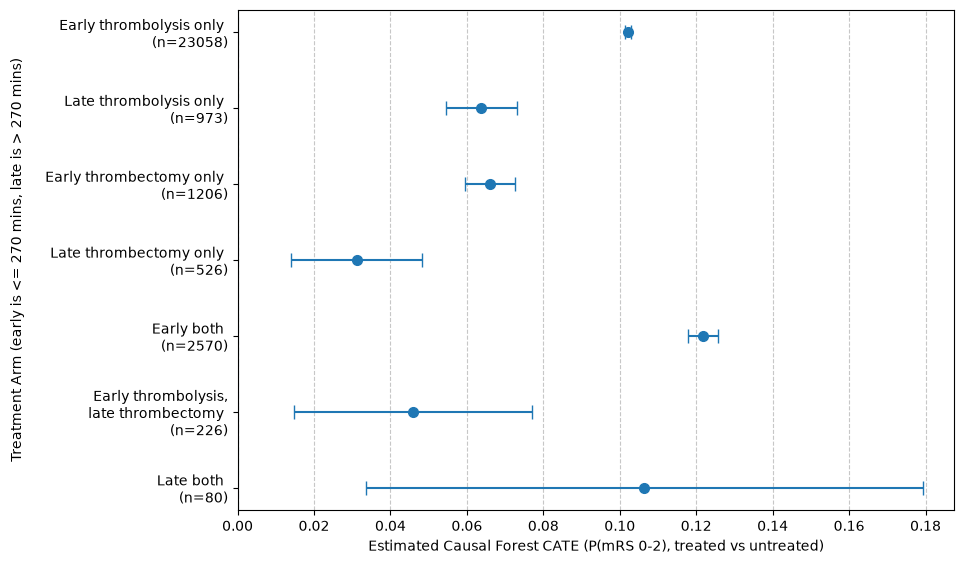

In [16]:
rename_dict = {
    "early_thrombolysis_only": "Early thrombolysis only",
    "late_thrombolysis_only": "Late thrombolysis only",
    "early_thrombectomy_only": "Early thrombectomy only",
    "late_thrombectomy_only": "Late thrombectomy only",
    "early_both": "Early both",
    "early_thrombolysis_late_thrombectomy": "Early thrombolysis,\nlate thrombectomy",
    "late_both": "Late both"
}
# Add n values to the y tick labels
n_values = cate_summary["count"].astype(int).to_dict()
rename_dict = {k: f"{v} \n(n={n_values.get(k, 0)})" for k, v in rename_dict.items()}

fig, ax = plt.subplots(figsize=(10, 6))
# Plot the mean CATE with error bars for 95% CI
ax.errorbar(
    y=range(len(cate_summary.index) - 1, -1, -1),
    x=cate_summary["mean"],
    xerr=[
        cate_summary["mean"] - cate_summary["95% CI lower"],
        cate_summary["95% CI upper"] - cate_summary["mean"],
    ],
    fmt="o",
    markersize=7,  # increase point size
    capsize=5,
    label="Estimated CATE with 95% CI",
)
# Make x min =0
ax.set_xlim(left=0)
# x_tick at 0.02 intervals
ax.set_xticks(np.arange(0, 0.181, 0.02))
# Add y tick labels for treatment arms
ax.set_yticks(range(len(cate_summary.index) - 1, -1, -1))
# For y tick labels replace _ with space
ax.set_yticklabels([rename_dict.get(label, label.replace('_', ' ')) for label in cate_summary.index])
# Label the axes
ax.set_xlabel(f"Estimated Causal Forest CATE (P(mRS 0-{MRS_TARGET}), treated vs untreated)")
ax.set_ylabel(f"Treatment Arm (early is <= {CUTOFF} mins, late is > {CUTOFF} mins)", labelpad=15)
# Add grid lines
ax.grid(axis="x", linestyle="--", alpha=0.7)
# Add a horizontal line at y=0
ax.axvline(x=0, linestyle="--", alpha=0.7)
plt.tight_layout(pad=2)
plt.savefig(f"./output/causal_forest_counterfactual_cate_estimates_{MRS_TARGET}.png", dpi=300)
plt.show()

## XGBoost

Use same X and y as Causal Forest model

In [17]:
X_cols = [
    'prior_disability', 'stroke_severity', 'age',
    'congestive_heart_failure', 'hypertension', 'diabetes',
    'afib_anticoagulant', 'any_afib_diagnosis','year',
    'onset_to_scan_time','ethnicity', 'stroke_team', 'treatment_group']

X = data[X_cols]
y = (data["discharge_disability"] <= MRS_TARGET).astype(int)

## Create 5 k-fold splits

In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_X_sets = []
train_y_sets = []
test_X_sets = []
test_y_sets = []

for train_index, test_index in skf.split(X, y):
    train_X, test_X = X.iloc[train_index], X.iloc[test_index]
    train_y, test_y = y.iloc[train_index], y.iloc[test_index]

    # Ensure categorical columns are pandas categorical dtype for XGBoost
    for col in CATEGORICAL_FEATURES:
        train_X[col] = train_X[col].replace("", "Empty")
        train_X[col] = train_X[col].astype("category")
        test_X[col] = test_X[col].replace("", "Empty")
        test_X[col] = test_X[col].astype("category")

    # Ensure non-categorical columns are numeric
    for col in NON_CATEGORICAL_FEATURES:
        train_X[col] = pd.to_numeric(train_X[col], errors="coerce")
        test_X[col] = pd.to_numeric(test_X[col], errors="coerce")

    train_X_sets.append(train_X)
    train_y_sets.append(train_y)
    test_X_sets.append(test_X)
    test_y_sets.append(test_y)

## Train and test models

In [19]:
models = []
test_y_pred_probas = []
test_y_preds = []

for split in range(5):
    # Get data for this split
    train_X = train_X_sets[split]
    train_y = train_y_sets[split]
    test_X = test_X_sets[split]
    test_y = test_y_sets[split]

    # Ensure categorical columns are pandas categorical dtype for XGBoost
    for col in CATEGORICAL_FEATURES:
        if col in train_X.columns:
            train_X[col] = train_X[col].replace("", "Empty")
            train_X[col] = train_X[col].astype("category")
        if col in test_X.columns:
            test_X[col] = test_X[col].replace("", "Empty")
            test_X[col] = test_X[col].astype("category")

    # Get data for weighting
    pos = train_y.sum()
    neg = len(train_y) - pos
    model = XGBClassifier(
        enable_categorical=True,
        verbosity=0,
        seed=42,
        eval_metric='logloss',
        # Scale weight manually adjusted so predictive positive rate
        # matched actual positive rate
        scale_pos_weight=(neg / pos) * 0.55 
    )
    # Train model
    model.fit(train_X, train_y)
    models.append(model)
    # Evaluate model with AUC and balanced accuracy
    y_pred_proba = model.predict_proba(test_X)[:, 1]
    y_pred = model.predict(test_X)
    auc = roc_auc_score(test_y, y_pred_proba)
    bal_acc = balanced_accuracy_score(test_y, y_pred)
    test_y_pred_probas.append(y_pred_proba)
    test_y_preds.append(y_pred)
    print(f"Split {split + 1}: AUC = {auc:.4f}, Balanced Accuracy = {bal_acc:.4f}")

Split 1: AUC = 0.8206, Balanced Accuracy = 0.7222
Split 2: AUC = 0.8267, Balanced Accuracy = 0.7266
Split 3: AUC = 0.8173, Balanced Accuracy = 0.7183
Split 4: AUC = 0.8233, Balanced Accuracy = 0.7293
Split 5: AUC = 0.8202, Balanced Accuracy = 0.7178


In [20]:
# Check predicted vs actual positive rates
for split in range(5):
    test_y = test_y_sets[split]
    y_pred_proba = test_y_pred_probas[split]
    y_pred = test_y_preds[split]

    actual_pos_rate = test_y.mean()
    predicted_pos_rate = y_pred.mean()

    print(
        f"Split {split + 1}: Actual positive rate = {actual_pos_rate:.4f}, "
        f"Predicted positive rate = {predicted_pos_rate:.4f}"
    )

Split 1: Actual positive rate = 0.3152, Predicted positive rate = 0.3217
Split 2: Actual positive rate = 0.3151, Predicted positive rate = 0.3186
Split 3: Actual positive rate = 0.3151, Predicted positive rate = 0.3136
Split 4: Actual positive rate = 0.3151, Predicted positive rate = 0.3182
Split 5: Actual positive rate = 0.3152, Predicted positive rate = 0.3131


## Predict counterfactual outcomes

To mimic no thrombolysis or thrombectomy, set times to 99999.

In [21]:
counter_factuals = []

for split in range(5):
    model = models[split]
    test_X = test_X_sets[split]
    test_X["treatment_group"]= test_X["treatment_group"].astype("category")

    # Predict probabilities for the test set
    predicted_proba = model.predict_proba(test_X)[:, 1]

    # Change treatment_group to "neither" for counterfactual prediction
    test_X_cf = test_X.copy(deep=True)
    # Set to 'neither' but keep the same dtype and categories
    test_X_cf["treatment_group"] = pd.Categorical(
        ["neither"] * len(test_X_cf),
        categories=test_X["treatment_group"].cat.categories,
        ordered=test_X["treatment_group"].cat.ordered
    )
    # Predict probabilities for the counterfactual set
    predicted_proba_cf = model.predict_proba(test_X_cf)[:, 1]

    # Store X, predicted probabilities, and counterfactual probabilities in a DataFrame
    cf_df = test_X.copy()
    cf_df["predicted_proba"] = predicted_proba
    cf_df["predicted_proba_cf"] = predicted_proba_cf
    cf_df["predicted_proba_shift"] = cf_df["predicted_proba"] - cf_df["predicted_proba_cf"]
    counter_factuals.append(cf_df)

# Concatenate all counterfactual DataFrames into a single DataFrame
counter_factuals_df = pd.concat(counter_factuals, ignore_index=True)

In [22]:
# Calculate mean, SD, and 95% CI of CATE for each treatment arm
counter_factual_summary = counter_factuals_df.groupby("treatment_group")["predicted_proba_shift"].agg(["mean", "std", "count"])
counter_factual_summary["95% CI lower"] = counter_factual_summary["mean"] - 1.96 * counter_factual_summary["std"] / np.sqrt(counter_factual_summary["count"])
counter_factual_summary["95% CI upper"] = counter_factual_summary["mean"] + 1.96 * counter_factual_summary["std"] / np.sqrt(counter_factual_summary["count"])

ordered_arms = [
    "early_thrombolysis_only",
    "late_thrombolysis_only",
    "early_thrombectomy_only",
    "late_thrombectomy_only",
    "early_both",
    "early_thrombolysis_late_thrombectomy",
    "late_both"
]
counter_factual_summary = counter_factual_summary.reindex(ordered_arms).round(4)
counter_factual_summary 

,mean,std,count,95% CI lower,95% CI upper
treatment_group,,,,,
early_thrombolysis_only,0.1080,0.0966,23058,0.1067,0.1092
late_thrombolysis_only,0.0662,0.1280,973,0.0582,0.0743
early_thrombectomy_only,0.0799,0.1234,1206,0.0729,0.0868
late_thrombectomy_only,0.0398,0.1703,526,0.0253,0.0544
early_both,0.1409,0.1237,2570,0.1361,0.1457
early_thrombolysis_late_thrombectomy,0.0398,0.1527,226,0.0199,0.0597
late_both,0.1093,0.1645,80,0.0733,0.1454


In [23]:
# Repeat last plotting code for counterfactual summary
ordered_arms = [
    "early_thrombolysis_only",
    "late_thrombolysis_only",
    "early_thrombectomy_only",
    "late_thrombectomy_only",
    "early_both",
    "early_thrombolysis_late_thrombectomy",
    "late_both"
]
counter_factual_summary = counter_factual_summary.reindex(ordered_arms).round(4)
counter_factual_summary 

,mean,std,count,95% CI lower,95% CI upper
treatment_group,,,,,
early_thrombolysis_only,0.1080,0.0966,23058,0.1067,0.1092
late_thrombolysis_only,0.0662,0.1280,973,0.0582,0.0743
early_thrombectomy_only,0.0799,0.1234,1206,0.0729,0.0868
late_thrombectomy_only,0.0398,0.1703,526,0.0253,0.0544
early_both,0.1409,0.1237,2570,0.1361,0.1457
early_thrombolysis_late_thrombectomy,0.0398,0.1527,226,0.0199,0.0597
late_both,0.1093,0.1645,80,0.0733,0.1454


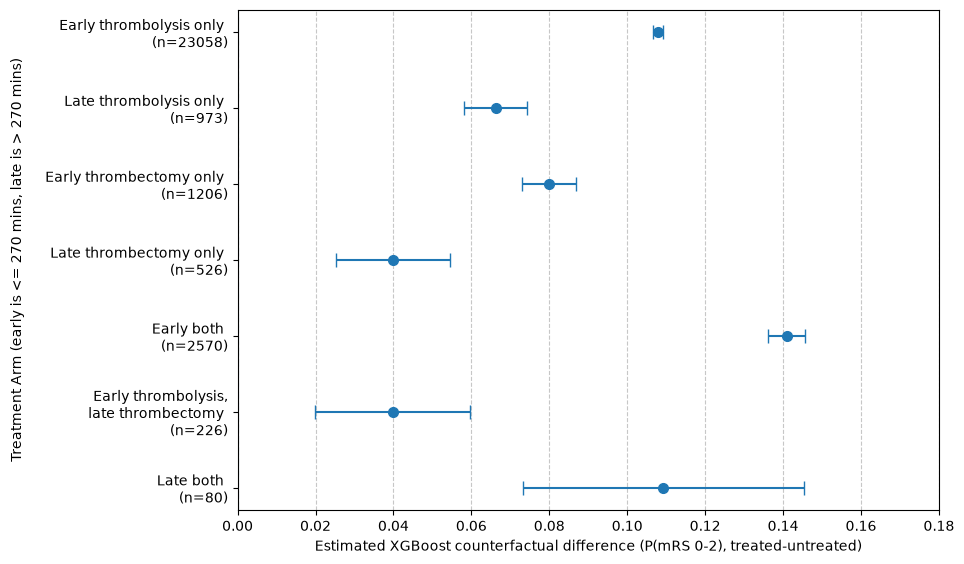

In [24]:
rename_dict = {
    "early_thrombolysis_only": "Early thrombolysis only",
    "late_thrombolysis_only": "Late thrombolysis only",
    "early_thrombectomy_only": "Early thrombectomy only",
    "late_thrombectomy_only": "Late thrombectomy only",
    "early_both": "Early both",
    "early_thrombolysis_late_thrombectomy": "Early thrombolysis,\nlate thrombectomy",
    "late_both": "Late both"
}
# Add n values to the y tick labels
n_values = cate_summary["count"].astype(int).to_dict()
rename_dict = {k: f"{v} \n(n={n_values.get(k, 0)})" for k, v in rename_dict.items()}

fig, ax = plt.subplots(figsize=(10, 6))
# Plot the mean prob shift with error bars for 95% CI
ax.errorbar(
    y=range(len(counter_factual_summary.index) - 1, -1, -1),
    x=counter_factual_summary["mean"],
    xerr=[
        counter_factual_summary["mean"] - counter_factual_summary["95% CI lower"],
        counter_factual_summary["95% CI upper"] - counter_factual_summary["mean"],
    ],
    fmt="o",
    markersize=7,  # increase point size
    capsize=5,
    label="Estimated CATE with 95% CI",
)
# Make x min =0
ax.set_xlim(left=0)
ax.set_xticks(np.arange(0, 0.181, 0.02))
# Add y tick labels for treatment arms
ax.set_yticks(range(len(counter_factual_summary.index) - 1, -1, -1))
# For y tick labels repolace _ with space
ax.set_yticklabels([rename_dict.get(label, label.replace('_', ' ')) for label in counter_factual_summary.index])
# Label the axes
ax.set_xlabel(f"Estimated XGBoost counterfactual difference (P(mRS 0-{MRS_TARGET}), treated-untreated)")

ax.set_ylabel(f"Treatment Arm (early is <= {CUTOFF} mins, late is > {CUTOFF} mins)", labelpad=15)
# Add grid lines
ax.grid(axis="x", linestyle="--", alpha=0.7)
# Add a horizontal line at y=0
ax.axvline(x=0, linestyle="--", alpha=0.7)
plt.tight_layout(pad=2)
plt.savefig(f"./output/xgboost_counterfactual_cate_estimates_{MRS_TARGET}.png", dpi=300)
plt.show()